# Deep Hedging

___
**Reference paper:**
- Deep Hedging - Buehler and al. 2018 
    https://arxiv.org/abs/1802.03042
- Equal risk pricing of financial derivative with deep hedging - Carbonneau, Godin. 2020
- Deep Learning - Goodfellow et al. 2016

**Reference code:**
- Equal risk pricing with deep hedging - Carbonneau
    https://github.com/alexandrecarbonneau/Equal-risk-pricing-with-deep-hedging/blob/master/Example%20of%20ERP%20with%20deep%20hedging.ipynb
- Deep Hedging
    https://nbviewer.org/urls/people.math.ethz.ch/~jteichma/lecture_ml_web/lecture_3.ipynb
- Option hedging with a Long-Short-Term-Memory Recurrent Neural Network mgroncki
    https://github.com/mgroncki/DataScienceNotebooks/blob/master/DeepHedging/DeepHedging_Part1.ipynb


___
# Objective

Implement a simple deep hedging framework to hedge an European call option on the underlying Black-Scholes model.

___
# 0. Packages

In [191]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from scipy.stats import norm

___
# 1. Hedging Problem

You are short a European call option. At each rebalancing step $t$, you hold $\delta_t$ shares of the underlying. The P&L of the hedged portfolio is:

$$\text{P\&L} = \text{Option Premium} - \text{Payoff}(S_T) + \sum_{t=0}^{T-1} \delta_t (S_{t+1} - S_t) - \text{Transaction Cost}$$

The goal is to learn $\delta_t = f_\theta(\text{state}_t)$ that minimizes a risk measure (e.g., CVaR) of the terminal P&L.

___
# 2. Black-Scholes Model

Recall in the Black-Scholes framework, the asset price $S_t$ a Geometric Brownian Motion (GBM):

$$
dS_t = r \, S_t \, dt + \sigma \, S_t \, dW_t
$$
where $r$ is the risk free rate, $\sigma$ is the volatility (constant), and $W_t$ is a standard Brownian motion with respect to the risk neutral measure $Q$.


Given $\mathcal{F}_s$ , $s \leq t$, we obtain, using Ito's,
$$
S_t = S_s \, e^{(r - \frac{\sigma^2}{2}) \, (t-s) \ + \ \sigma  \, (W_t - W_s)}
$$
Equivalent to 
$$
S_t = S_s \, e^{(r - \frac{\sigma^2}{2}) \, (t-s) \ + \ \sigma \, \sqrt{t-s} \, Z_t}
$$
where $Z_t \sim \mathcal{N}(0,1)$

### (a) Simulate BS paths

In [192]:
def BS_paths(S0, r, sigma, T, N_steps, M_paths, seed = 123):
    """
    This function simulate (M_paths) Black-Scholes paths from 0 to maturity T,
    with number of discretization (N_steps)
    return shape is (N_steps + 1, M_paths + 1), 
    e.g. first column is each column is a simulation
    """
    np.random.seed(seed)
    dt = T / N_steps
    Z = np.random.randn(M_paths, N_steps)
    log_return = (r - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z
    log_S = np.log(S0) + np.cumsum(log_return, axis=1)
    S = np.exp(log_S)
    S = np.column_stack([np.full(M_paths, S0), S])
    t = np.linspace(0, T, N_steps + 1)

    return S.astype(np.float32), t


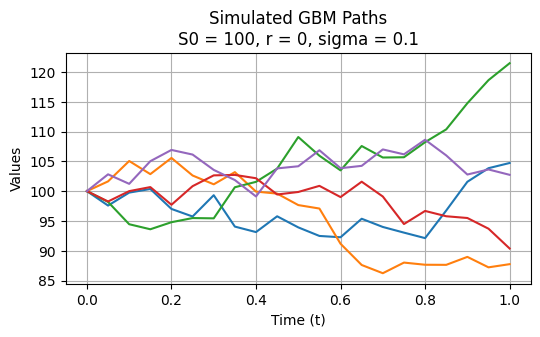

In [193]:
r = 0
sigma = 0.1
S0 = 100
S, t = BS_paths(S0 = S0, r = r, sigma = sigma, T = 1, N_steps = 20, M_paths = 5)

plt.figure(figsize=(6, 3)) 
plt.plot(t, np.transpose(S), label='S_t')

plt.title(f'Simulated GBM Paths\nS0 = {S0}, r = {r}, sigma = {sigma}')    
plt.xlabel('Time (t)')
plt.ylabel('Values')
plt.grid()
plt.show()

### (b) Black-Scholes Hedging Framework

The Black-Scholes European call price is:
$$
C(S, t) = S\, \Phi(d_1) - K e^{-r(T-t)} \Phi(d_2)
$$

where $\Phi(\cdot)$ is the standard normal CDF and:
$$
d_1 = \frac{\ln(S/K) + \left(r + \frac{1}{2}\sigma^2\right)(T-t)}{\sigma\sqrt{T-t}}, \qquad d_2 = d_1 - \sigma\sqrt{T-t}
$$

Taking the first partial derivative with respect to the asset price $S$ (called *delta*)
$$
\delta = \frac{\partial C}{\partial S} = \Phi(d_1)
$$
with $\delta \in [0,1]$ (by cdf of normal)


In the Black-Scholes delta hedging framework, the rebalancing rule is:

At each time step $t$, hold $\delta_t$ shares of the underlying $S_t$:

$$\delta_t = \Phi(d_1(S_t, t))$$

The hedge P&L accumulated over one step is:

$$\text{PnL}_t = \delta_{t-1} \cdot (S_t - S_{t-1})$$

and the total hedged portfolio value at maturity is:

$$\text{PnL}_{\text{total}} = \text{Call Premium} + \sum_{t=1}^{T} \text{PnL}_t - \text{Payoff}$$

##### Option pricing with Black Scholes

In [194]:
class BlackScholes:
    def __init__(self, S, K, r, sigma, T):
        self.S = S   # current asset price
        self.K = K   # strike
        self.r = r   # risk free rate
        self.sigma = sigma   #volatility
        self.T = T   # time to maturity

    def call_price(self):  
        d1 = (np.log(self.S/self.K) + (self.r + 0.5*(self.sigma**2))*self.T)/(self.sigma * np.sqrt(self.T))
        d2 = d1 - self.sigma*np.sqrt(self.T)
        return self.S*norm.cdf(d1) - self.K*np.exp(-self.r*self.T)*norm.cdf(d2)
    def put_price(self):  # by put call parity
        return self.call_price() - self.S + self.K*np.exp(-self.r * self.T)
    
    def call_delta(self):  # first derivative with respect to price S 
        d1 = (np.log(self.S/self.K) + (self.r + 0.5*(self.sigma**2))*self.T)/(self.sigma * np.sqrt(self.T))
        return norm.cdf(d1)
    def put_delta(self):   # by derivative of put-call parity with respect to S
        return self.call_delta() - 1

##### Delta Hedging with Black Scholes

In [195]:
def delta_hedging(S, K, r, sigma, T, Initial_portfolio=0):
    # parameters
    ttm = np.linspace(T, 0,S.shape[1])
    dt = T/(S.shape[1] - 1)

    # call price value (initial value of the hedging portfolio)
    call_price_maturity = np.full(S.shape[0], Initial_portfolio) * np.exp(r * T)

    # payoff (at maturity)
    payoff = np.maximum(S[:,-1] - K, 0)

    # delta (not at maturity)
    S_grid = S[:,:-1]
    T_grid = ttm[:-1]
    
    d1 = (np.log(S_grid/K) + (r + 0.5*(sigma**2))*T_grid)/(sigma * np.sqrt(T_grid))
    deltas = norm.cdf(d1)

    # pnl at each step t = 1 to T-1 

    compound = np.exp(r * (T - ttm[1:]))      # compounding each gain to maturity
    dS = S[:, 1:] - S[:, :-1] * np.exp(r * dt)         # discounted stock move
    hedging_pnl = np.sum(deltas * dS * compound, axis=1)

    # total pnl
    pnl = call_price_maturity + hedging_pnl - payoff

    return pnl

___
# 3. Deep Hedging

### (a) Introduction

To introduce the concept of deep hedging, let first consider a market with no friction (e.g. no transaction cost, no market impacts). Note that the following framework can be adjusted for market friction.

### (b) Set Up

### (c) Deep Hedging Implementation

##### Create Deep Hedging Class

In [196]:
class DeepHedging(nn.Module):
    """
    Feed forward neural network with 2 hidden layers and 64 neurons each,
    - 2 inputs: (delta_{t-1}, S_t) e.g. last position, stock price
    - Activation function: ReLU
    - Output function: Sigmoid (ensure delta in [0,1])
    """
    def __init__(self, num_features=2, hidden_size=64):
        super().__init__()
        self.num_features = num_features
        self.hidden_size = hidden_size
        self.net = nn.Sequential(
            nn.Linear(num_features, hidden_size), nn.ReLU(),
            nn.Linear(hidden_size, hidden_size), nn.ReLU(),
            nn.Linear(hidden_size, 1), nn.Sigmoid()
        )
        
    def forward(self, x):
        return self.net(x)

##### P&L function *(Intermediary Output)*

In [197]:
def calc_pnl(S, deltas, K, r, T, dt, Initial_portfolio):
    """
    Calculates the PnL of the hedging strategy.
    The PnL function is the same as the Black-Scholes delta hedging.
    Only difference is that deltas are not BlackScholes but NN optimized

    S : (N_paths, N_steps + 1)
    deltas : (N_paths, N_steps)
    K : strike price, r : risk-free rate, T : time to maturity, dt : time step
    Initial_portfolio : initial value of the hedging portfolio
    """
    # hedging steps pnl
    ttm = torch.linspace(T, 0, S.shape[1])  #(N_steps + 1,)
    compound = torch.exp(r * (T - ttm[1:]))    #(N_steps,)  
    dS = S[:, 1:] - S[:, :-1] * torch.exp(torch.tensor(r * dt))  #(N_paths, N_steps)        
    hedging_pnl = torch.sum(deltas * dS * compound, axis=1)  #(N_paths,)

    # Maturity value of the initial portfolio
    initial_value_maturity = Initial_portfolio * torch.exp(torch.tensor(r * T)) #(N_paths,)
    
    # Payoff at maturity
    payoff = torch.relu(S[:,-1] - K)    #(N_paths,)

    # total pnl
    pnl = initial_value_maturity + hedging_pnl - payoff   #(N_paths,)

    return pnl   #(N_paths,)

##### Risk Measures (Convex)

In [198]:
def variance_loss(pnl):
    """
    Variance loss function.
    """
    return torch.var(pnl)  # to minimize

def cvar_loss(pnl, alpha=0.95):
    """
    Conditional Value at Risk (CVaR) loss function.
    """
    losses = -pnl  # losses are negative pnl
    var = torch.quantile(losses, alpha).detach()   # VaR estimate
    cvar = var + (1 / (1 - alpha)) * torch.mean(torch.relu(losses - var))  #CVaR formula (omit negative losses)
    return cvar  # to minimize

##### Training Loops

In [199]:
def train_deep_hedger(S, K, r, T, Initial_portfolio, risk='cvar', alpha=0.95,
                      hidden_size=64, lr=1e-3, n_epochs=500):
    """
    Train deep hedging NN given simulated paths
    """
    # parameters
    N_paths, N_steps_plus_1 = S.shape
    N_steps = N_steps_plus_1 - 1
    S0 = S[0,0]
    dt = T / N_steps

    # Convert paths to torch tensor
    paths = torch.tensor(S, dtype=torch.float32)  #(N_paths, N_steps + 1)
    
    # 2 Features : log-moneyness and time to maturity
    log_moneyness = torch.log(paths[:, :-1] / K)  #(N_paths, N_steps)
    ttm = torch.linspace(T, 0, N_steps + 1)[1:]  #(N_steps,)
    ttm_grid = ttm.unsqueeze(0).expand(N_paths, -1)  #(N_paths, N_steps)
    features = torch.stack([log_moneyness, ttm_grid], dim=2)       # (n_paths, n_steps, 2)

    # Model
    model = DeepHedging(num_features=2, hidden_size=hidden_size)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    print(f"\nTraining Deep Hedger with {risk} loss, alpha={alpha}, hidden_size={hidden_size}, lr={lr}, n_epochs={n_epochs}")
    for epoch in range(n_epochs + 1):
        optimizer.zero_grad()

        # forward pass: get delta at every path and step simultaneously
        deltas = model(features.view(-1, 2)).view(N_paths, N_steps)  # (N_paths, N_steps)

        pnl  = calc_pnl(paths, deltas, K, r, T, dt, Initial_portfolio)  #(N_paths,)
        loss = cvar_loss(pnl, alpha) if risk == 'cvar' else variance_loss(pnl)

        loss.backward()
        optimizer.step()

        if epoch % 100 == 0:
            print(f"Epoch {epoch:4d} | loss = {loss.item():.4f} | mean P&L = {pnl.mean().item():.4f} | std = {pnl.std().item():.4f}")

    return model

##### Test model

In [200]:
def test_deephedging(model, S, K, r, T, Initial_portfolio, risk='cvar', alpha=0.95):
    # Generate new test paths
    S_test = torch.tensor(S, dtype=torch.float32)   # (N_paths, N_steps+1)

    # Build features (same as training)
    N_paths, N_steps_p1 = S_test.shape
    N_steps = N_steps_p1 - 1
    dt = T / N_steps
    log_moneyness = torch.log(S_test[:, :-1] / K)  #(N_paths, N_steps)
    ttm = torch.linspace(T, 0, N_steps + 1)[1:]  #(N_steps,)
    ttm_grid = ttm.unsqueeze(0).expand(N_paths, -1)  #(N_paths, N_steps)
    features_test = torch.stack([log_moneyness, ttm_grid], dim=2)

    # Run model
    model.eval()
    with torch.no_grad():
        deltas_test = model(features_test.view(-1, 2)).view(N_paths, N_steps)
        pnl_test = calc_pnl(S_test, deltas_test, K, r, T, dt, Initial_portfolio)

    if risk == 'cvar':
        print(f"\nTest results for CVaR {alpha*100:.0f}% risk measure:\
              \nloss : {cvar_loss(pnl_test, alpha=alpha).item():.4f} | mean P&L : {pnl_test.mean().item():.4f} | std : {pnl_test.std().item():.4f}")
    else:
        print(f"\nTest results for Variance risk measure:\
              \nloss : {variance_loss(pnl_test).item():.4f} | mean P&L : {pnl_test.mean().item():.4f} | std : {pnl_test.std().item():.4f}")

### (d) Results

In [201]:
# test results

#simulate training paths (Black-Scholes)
S_train, t = BS_paths(S0 = 100, r = 0, sigma = 0.1, T = 1, N_steps = 1000, M_paths = 1000,seed=123)
Initial_portfolio_train = BlackScholes(S=100, K=100, r=0, sigma=0.1, T=1).call_price()

#simulate test paths (Black-Scholes)
S, t = BS_paths(S0 = 100, r = 0, sigma = 0.1, T = 1, N_steps = 1000, M_paths = 1000, seed=456)
Initial_portfolio = BlackScholes(S=100, K=100, r=0, sigma=0.1, T=1).call_price()
print(f"Initial portfolio value = {Initial_portfolio:.4f} (call option premium)")

#BS delta hedging P&L
delta_hedging_pnl = delta_hedging(S=S, K=100, r=0, sigma=0.1, T=1, Initial_portfolio=Initial_portfolio)
print(f"\nBlack-Scholes: mean P&L = {np.mean(delta_hedging_pnl):.4f} | std = {np.std(delta_hedging_pnl):.4f}")

#Deep hedging P&L
model = train_deep_hedger(S_train, K=100, r=0, T=1, Initial_portfolio=Initial_portfolio_train, risk='cvar', alpha=0.95)
test_model = test_deephedging(model, S, K=100, r=0, T=1, Initial_portfolio=Initial_portfolio, risk='cvar', alpha=0.95)

Initial portfolio value = 3.9878 (call option premium)

Black-Scholes: mean P&L = -0.0000 | std = 0.1092

Training Deep Hedger with cvar loss, alpha=0.95, hidden_size=64, lr=0.001, n_epochs=500
Epoch    0 | loss = 9.1647 | mean P&L = -0.0154 | std = 3.3125
Epoch  100 | loss = 6.4055 | mean P&L = 0.0197 | std = 2.6699
Epoch  200 | loss = 1.2257 | mean P&L = 0.0396 | std = 0.7975
Epoch  300 | loss = 0.9567 | mean P&L = 0.0306 | std = 0.6357
Epoch  400 | loss = 0.7617 | mean P&L = 0.0273 | std = 0.6074
Epoch  500 | loss = 0.6506 | mean P&L = 0.0252 | std = 0.5470

Test results for CVaR 95% risk measure:              
loss : 0.6837 | mean P&L : -0.0022 | std : 0.5206


### (e) Analyse Results

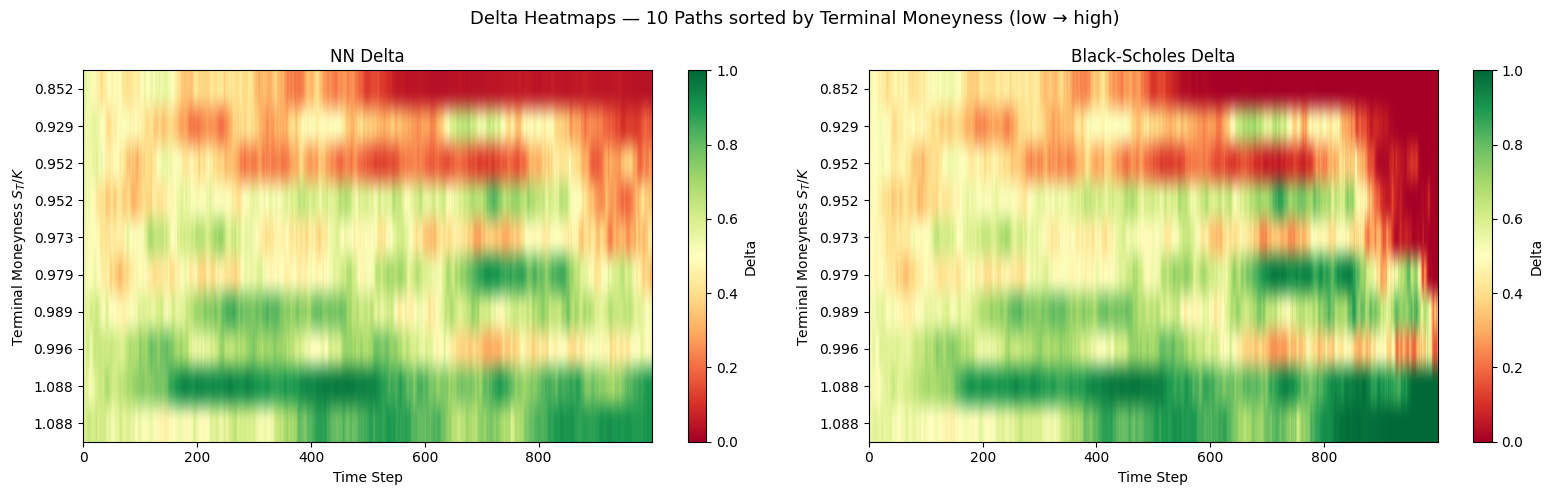

In [219]:

# --- Extract NN deltas on test paths ---
K_plot, r_plot, sigma_plot, T_plot = 100, 0, 0.1, 1

model.eval()
with torch.no_grad():
    S_test_tensor = torch.tensor(S, dtype=torch.float32)
    N_paths_plot, N_steps_p1 = S_test_tensor.shape
    N_steps_plot = N_steps_p1 - 1
    log_moneyness_plot = torch.log(S_test_tensor[:, :-1] / K_plot)
    ttm_plot = torch.linspace(T_plot, 0, N_steps_p1)[1:]
    ttm_grid_plot = ttm_plot.unsqueeze(0).expand(N_paths_plot, -1)
    features_plot = torch.stack([log_moneyness_plot, ttm_grid_plot], dim=2)
    nn_deltas = model(features_plot.view(-1, 2)).view(N_paths_plot, N_steps_plot).numpy()

# --- Extract BS deltas on test paths ---
ttm_np = np.linspace(T_plot, 0, S.shape[1])[:-1]
d1_plot = (np.log(S[:, :-1] / K_plot) + (r_plot + 0.5 * sigma_plot**2) * ttm_np) / (sigma_plot * np.sqrt(ttm_np))
bs_deltas = norm.cdf(d1_plot)

# Filter first 10 paths then sort by terminal moneyness S_T/K (low to high)
terminal_moneyness = S[:10, -1] / K_plot
sort_idx = np.argsort(terminal_moneyness)
nn_deltas_plot = nn_deltas[:10][sort_idx]
bs_deltas_plot = bs_deltas[:10][sort_idx]
ytick_labels = [f"{terminal_moneyness[i]:.3f}" for i in sort_idx]

# --- Heatmap: NN vs BS deltas ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

im1 = axes[0].imshow(nn_deltas_plot, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1, origin='upper')
axes[0].set_title('NN Delta')
axes[0].set_xlabel('Time Step')
axes[0].set_ylabel('Terminal Moneyness $S_T/K$')
axes[0].set_yticks(range(10))
axes[0].set_yticklabels(ytick_labels)
plt.colorbar(im1, ax=axes[0], label='Delta')

im2 = axes[1].imshow(bs_deltas_plot, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1, origin='upper')
axes[1].set_title('Black-Scholes Delta')
axes[1].set_xlabel('Time Step')
axes[1].set_ylabel('Terminal Moneyness $S_T/K$')
axes[1].set_yticks(range(10))
axes[1].set_yticklabels(ytick_labels)
plt.colorbar(im2, ax=axes[1], label='Delta')

plt.suptitle('Delta Heatmaps — 10 Paths sorted by Terminal Moneyness (low → high)', fontsize=13)
plt.tight_layout()
plt.show()


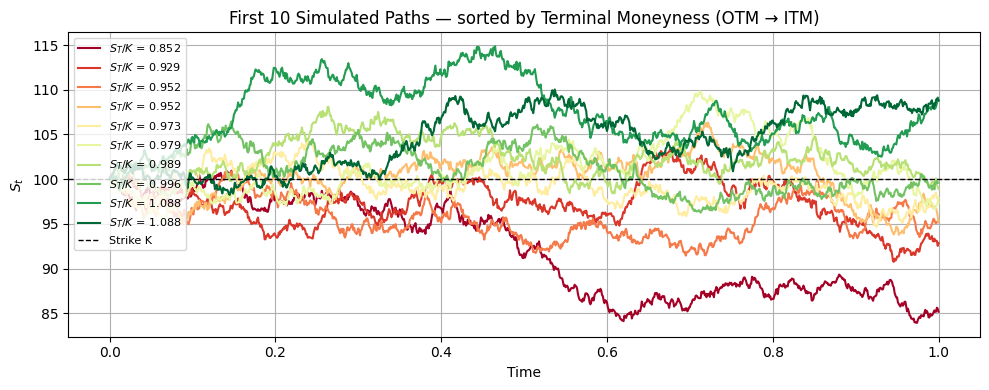

In [220]:

# --- Plot first 10 paths sorted by terminal moneyness ---
T_plot = 1
K_plot = 100
t_grid = np.linspace(0, T_plot, S.shape[1])

terminal_moneyness_all = S[:10, -1] / K_plot
sort_idx_paths = np.argsort(terminal_moneyness_all)
S_sorted = S[:10][sort_idx_paths]

cmap = plt.cm.RdYlGn
colors = [cmap(i / 9) for i in range(10)]

plt.figure(figsize=(10, 4))
for i, (path, color) in enumerate(zip(S_sorted, colors)):
    m = terminal_moneyness_all[sort_idx_paths[i]]
    plt.plot(t_grid, path, color=color, label=f'$S_T/K$ = {m:.3f}')

plt.axhline(K_plot, color='black', linestyle='--', linewidth=1, label='Strike K')
plt.title('First 10 Simulated Paths — sorted by Terminal Moneyness (OTM → ITM)')
plt.xlabel('Time')
plt.ylabel('$S_t$')
plt.legend(loc='upper left', fontsize=8)
plt.grid()
plt.tight_layout()
plt.show()


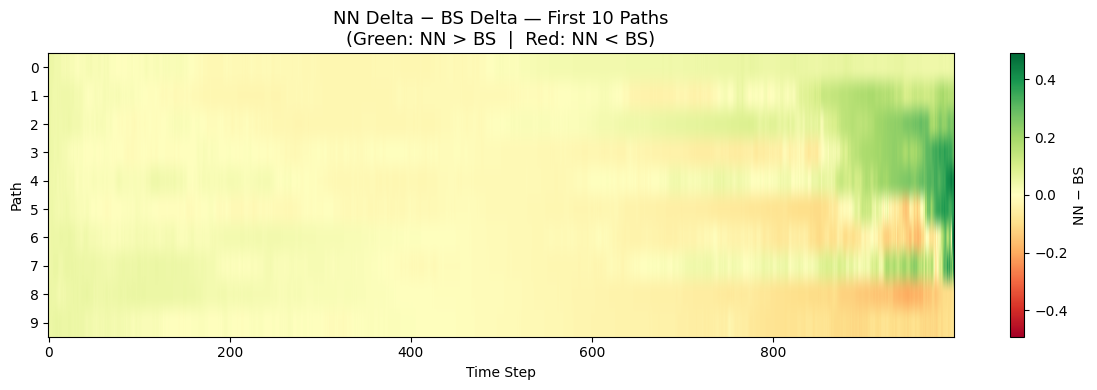

Mean difference (NN - BS): 0.0077
Std  difference (NN - BS): 0.0686


In [221]:

# --- Difference heatmap: NN - BS (first 10 paths) ---
diff = nn_deltas_plot - bs_deltas_plot
vmax = np.abs(diff).max()

fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(diff, aspect='auto', cmap='RdYlGn', vmin=-vmax, vmax=vmax, origin='upper')
ax.set_title('NN Delta − BS Delta — First 10 Paths\n(Green: NN > BS  |  Red: NN < BS)', fontsize=13)
ax.set_xlabel('Time Step')
ax.set_ylabel('Path')
ax.set_yticks(range(10))
plt.colorbar(im, ax=ax, label='NN − BS')
plt.tight_layout()
plt.show()

print(f"Mean difference (NN - BS): {diff.mean():.4f}")
print(f"Std  difference (NN - BS): {diff.std():.4f}")
